### 1. INTRODUCTION AND DATASET OVERVIEW

In [ ]:
DATASET OVERVIEW:

DATASET NAME    : OPEN UNIVERSITY LEARNING ANALYTICS DATASET

SOURCE          : https://analyse.kmi.open.ac.uk/#open-dataset - OU open learning data

PROBLEM TYPE    : CLASSIFICATION

TARGET VARIABLE : final_result (Categories: Pass,fail,distinction,withdrawn)

PURPOSE         : Prediction of final academic performance using student activity data

1.1 IMPORT LIBRARIES

In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


### 2. DATA PRE-PROCESSING AND CLEANING

2.1 DATA LOADING

In [8]:
file_path = r'E:\DM\DM PROJECT\merged_studentInfo.csv'
merged = pd.read_csv(file_path)

2.2 DATA PRE-PROCESSING AND CLEANING

In [ ]:

# Check and handling missing values

print("Missing Values Before Cleaning:\n", merged.isnull().sum()[merged.isnull().sum() > 0])

# No rows were dropped due to the missing values instead they were imputed with zero
# imputing missing total_clicks and avg_score with 0

merged['total_clicks'] = merged['total_clicks'].fillna(0)
merged['avg_score'] = merged['avg_score'].fillna(0)

# All categorical variables were label encoded 

categorical_columns = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
le = LabelEncoder()
for col in categorical_columns:
    merged[col] = le.fit_transform(merged[col])

# All duplicate rows are removed

merged.drop_duplicates(inplace=True)
print("Total Missing Values After Cleaning:", merged.isnull().sum().sum())

cleaned_file_path = r'E:\DM\DM PROJECT\cleaned_merged_studentInfo.csv'
merged.to_csv(cleaned_file_path, index=False)
print(f"Cleaned dataset saved successfully to {cleaned_file_path}")


Missing Values Before Cleaning:
 imd_band        1111
total_clicks    3365
avg_score       5866
dtype: int64
Total Missing Values After Cleaning: 0
Cleaned dataset saved successfully to E:\DM\DM PROJECT\cleaned_merged_studentInfo.csv


### 3. EXPLORATORY DATA ANALYSIS (EDA)

Dataset Overview
Shape of the dataset: (32593, 14)

Data types:
 code_module              object
code_presentation        object
id_student                int64
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
final_result             object
total_clicks            float64
avg_score               float64
dtype: object

First five rows:
   code_module code_presentation  id_student  gender  region  \
0         AAA             2013J       11391       1       0   
1         AAA             2013J       28400       0       6   
2         AAA             2013J       30268       0       5   
3         AAA             2013J       31604       0       7   
4         AAA             2013J       32885       0      11   

   highest_education  imd_band  age_band  num_of_prev_attempts  \
0        

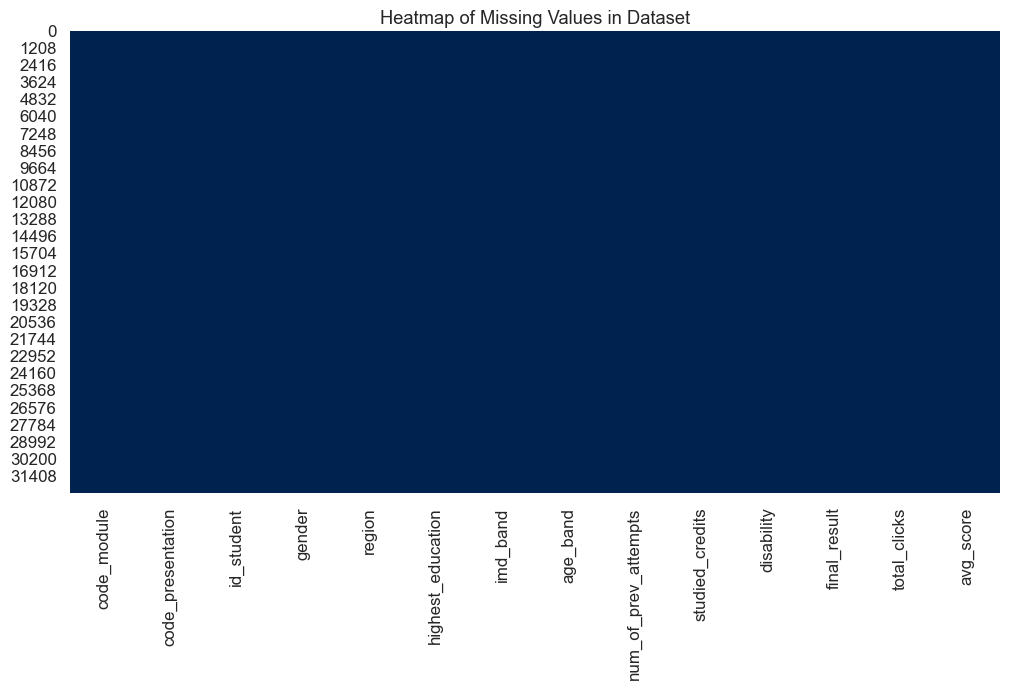

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='final_result', data=df, palette='Set2')


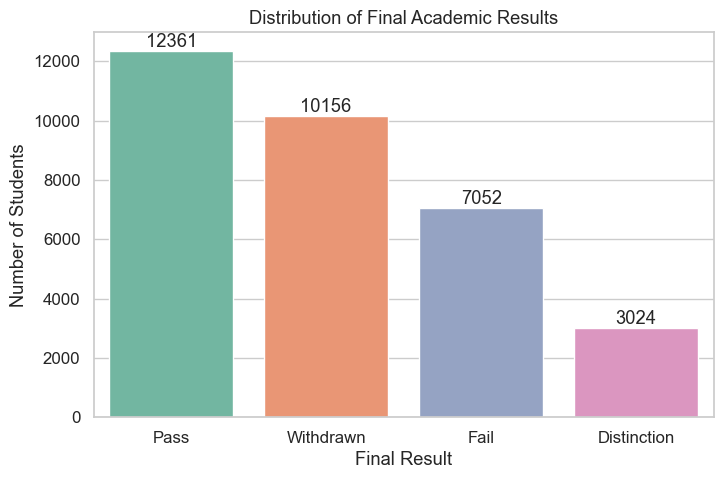

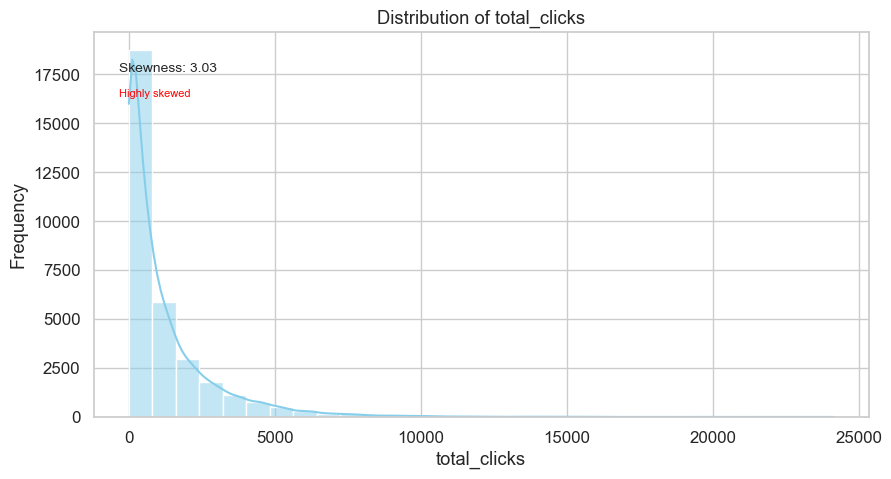

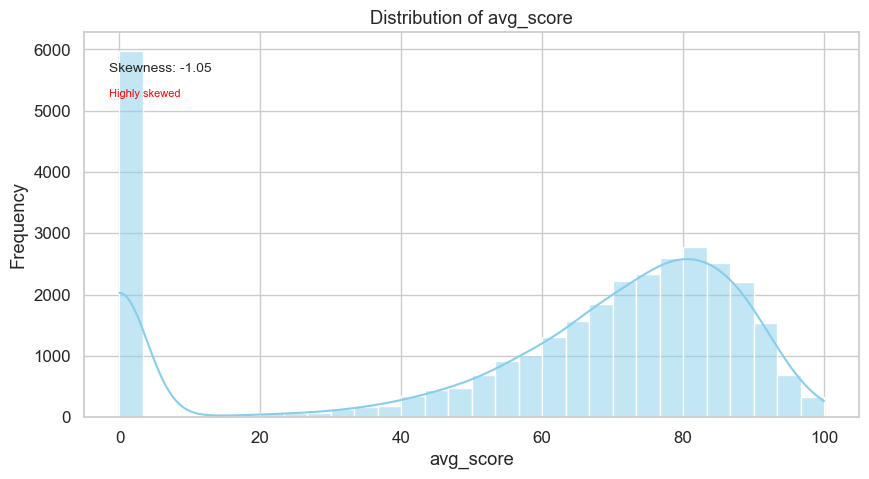

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


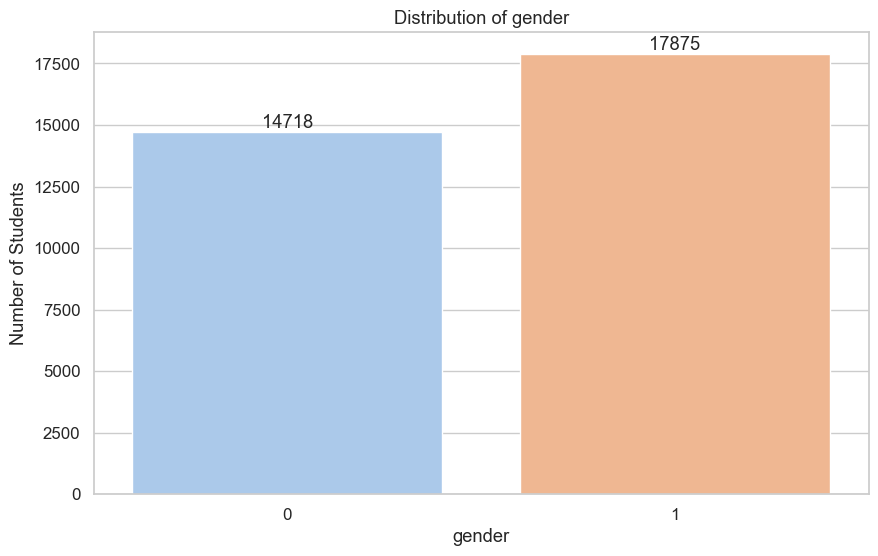

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


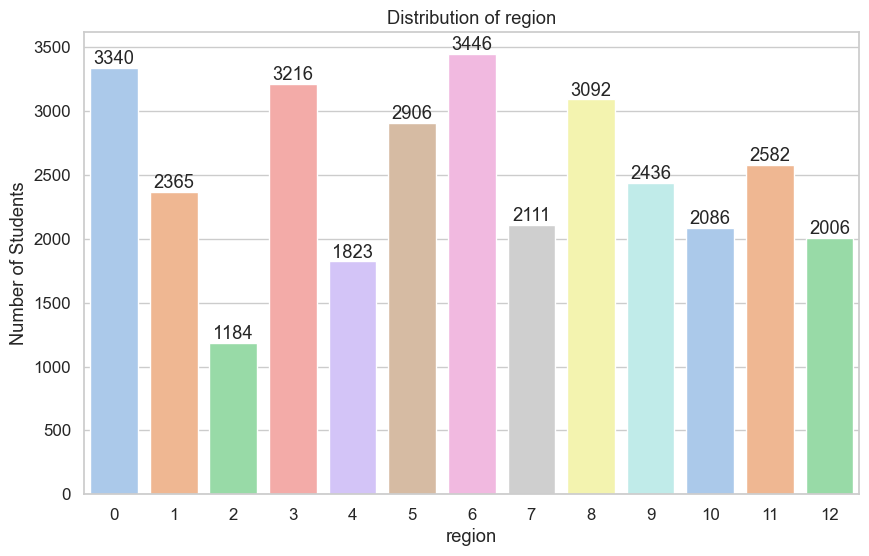

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


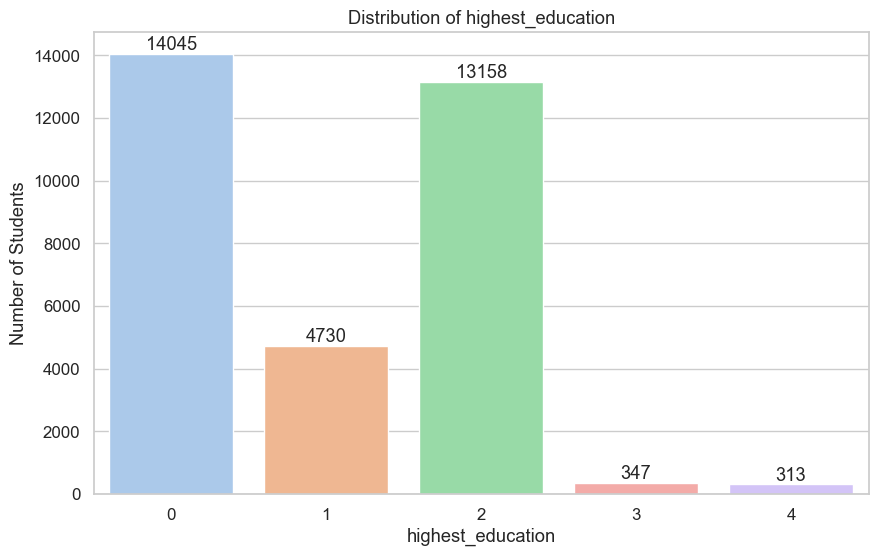

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


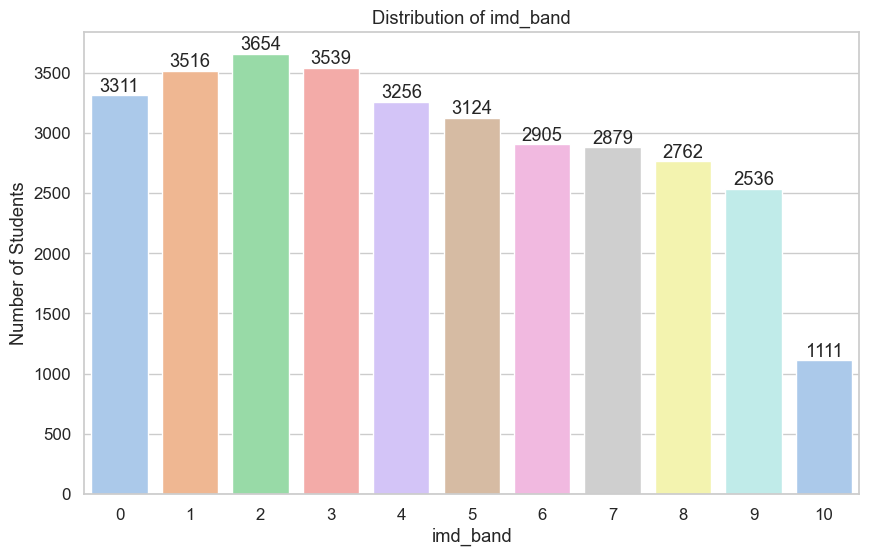

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


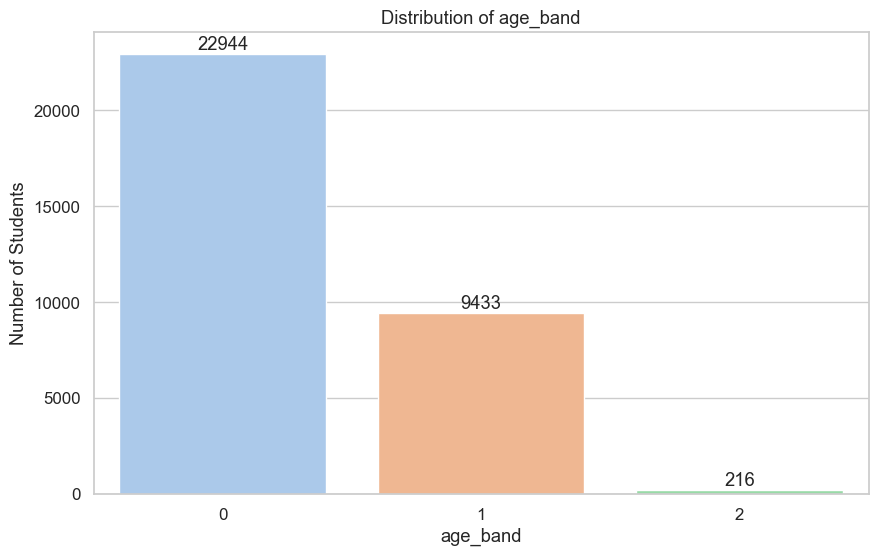

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=feature, data=df, palette='pastel')


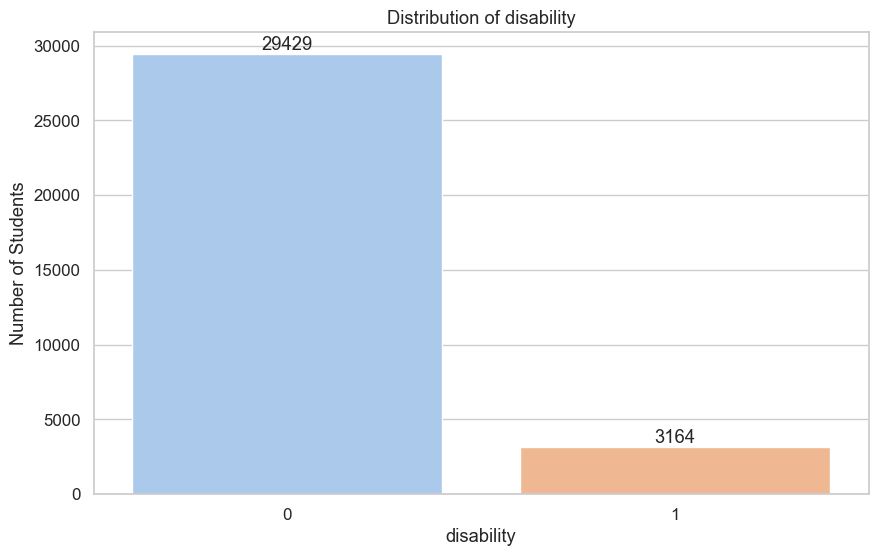

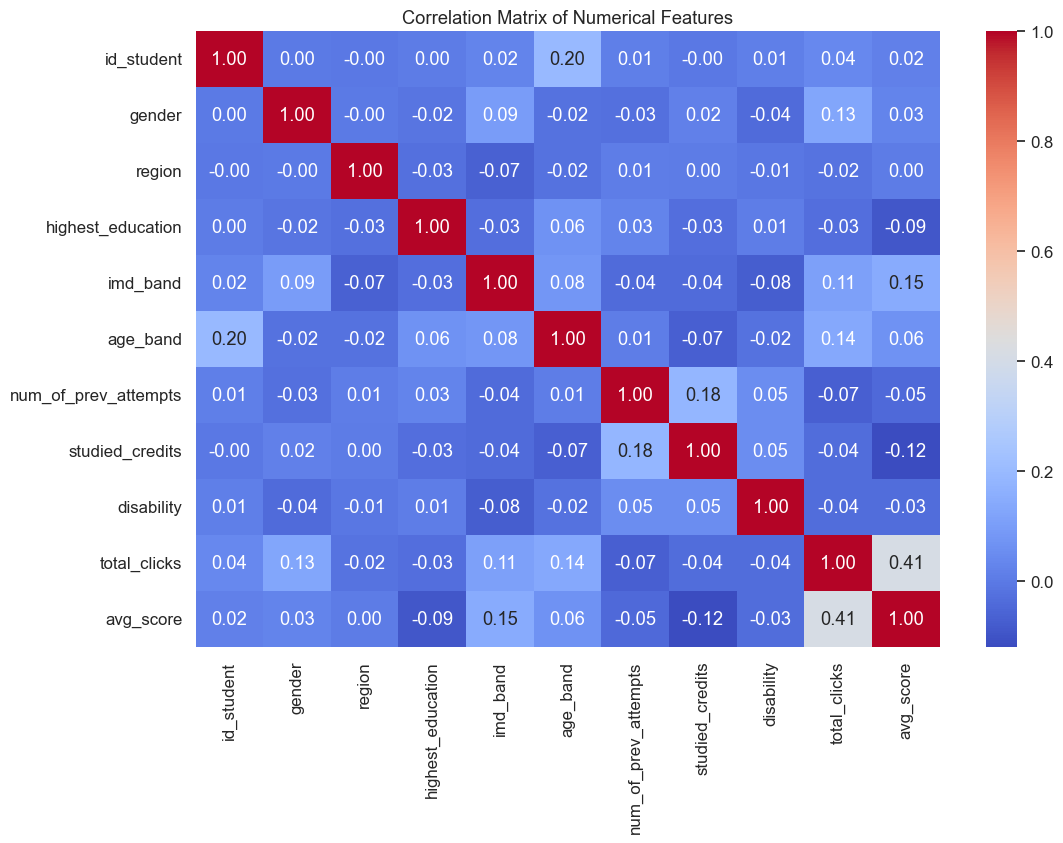

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_result', y=feature, data=df, palette='Set3')


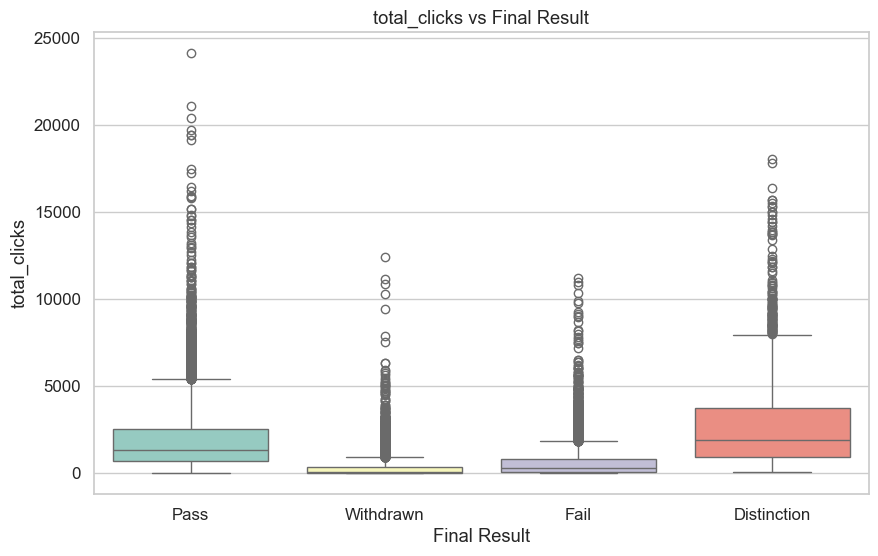

C:\Users\ACER\AppData\Local\Temp\ipykernel_27704\1142429990.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_result', y=feature, data=df, palette='Set3')


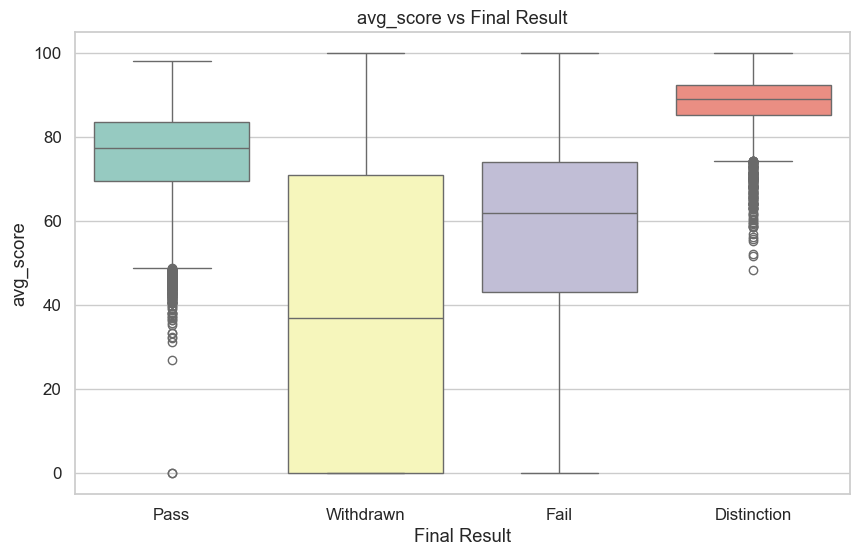

<Figure size 1000x600 with 0 Axes>

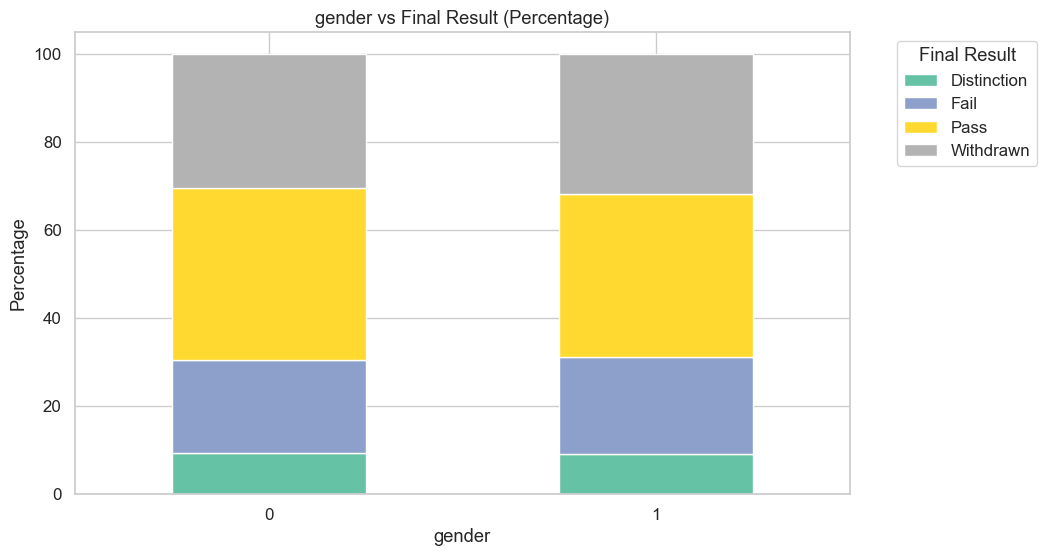

<Figure size 1000x600 with 0 Axes>

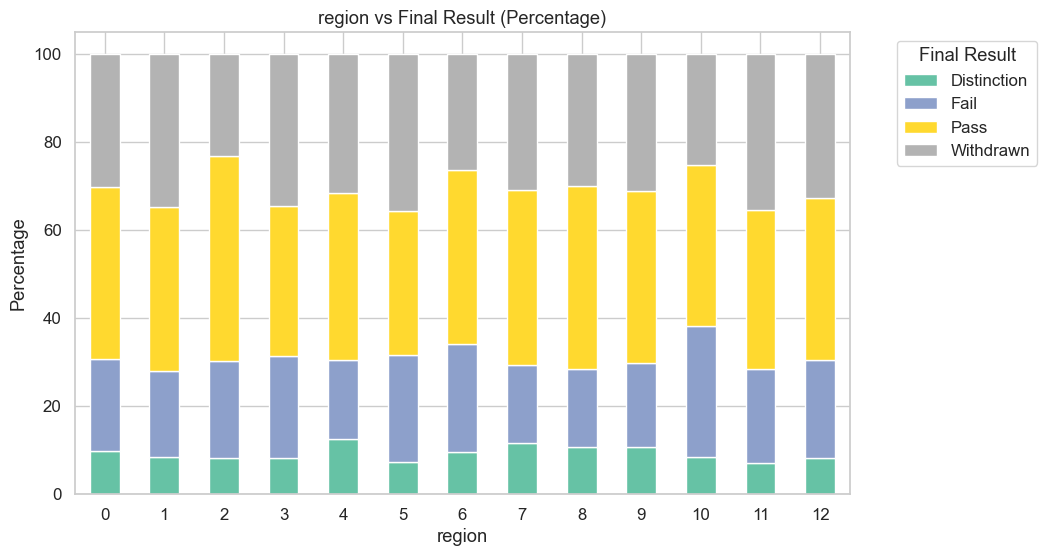

<Figure size 1000x600 with 0 Axes>

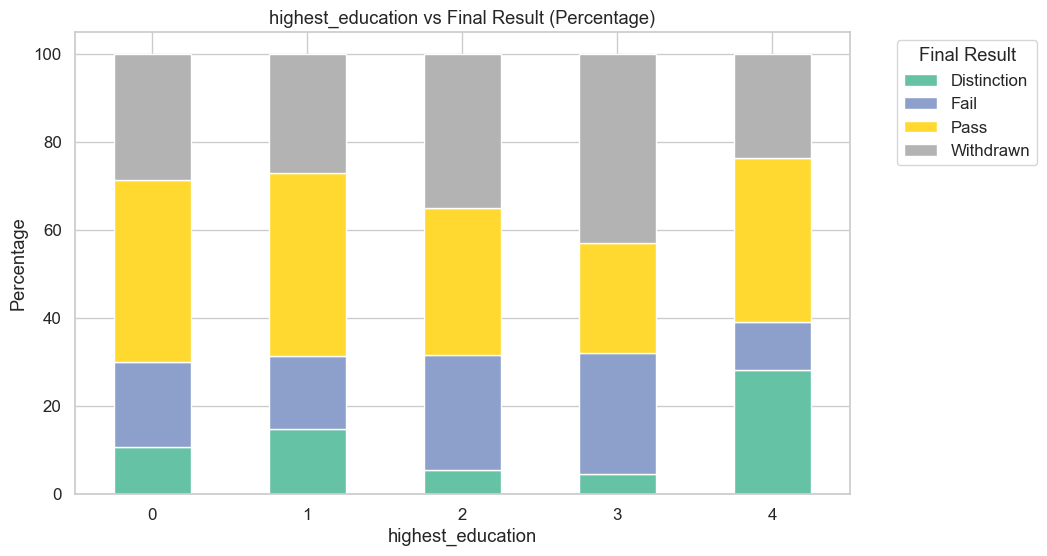

<Figure size 1000x600 with 0 Axes>

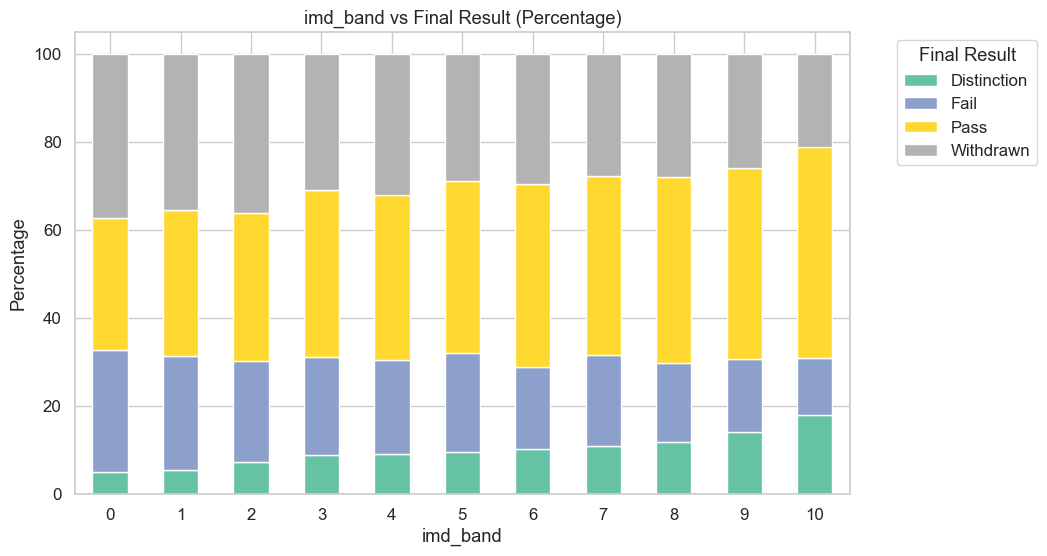

<Figure size 1000x600 with 0 Axes>

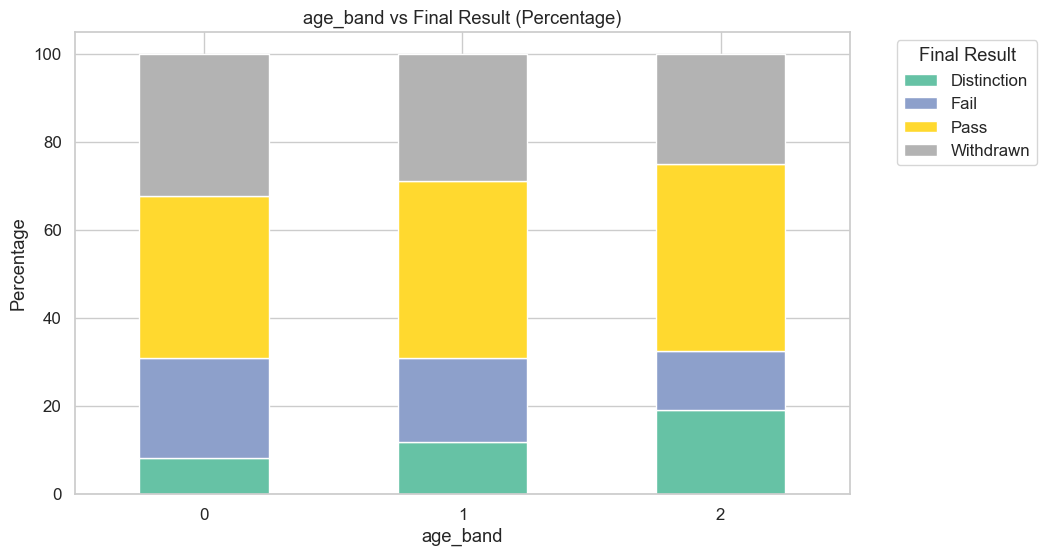

<Figure size 1000x600 with 0 Axes>

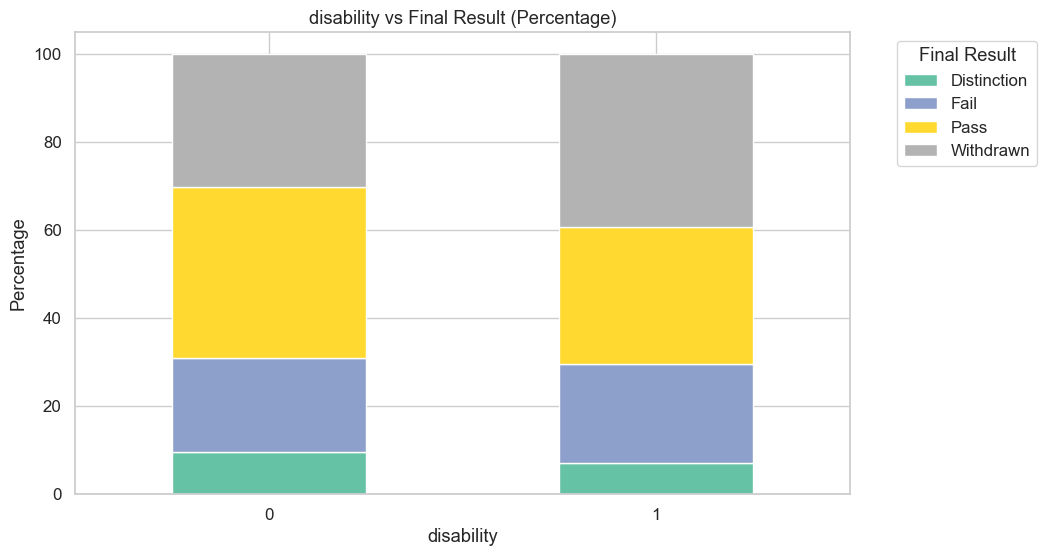

In [36]:

# plot theme
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

file_path = r'E:\DM\DM PROJECT\cleaned_merged_studentInfo.csv'
df = pd.read_csv(file_path)

# Dataset Overview
print("="*60)
print("Dataset Overview")
print("="*60)
print(f"Shape of the dataset: {df.shape}")
print("\nData types:\n", df.dtypes)
print("\nFirst five rows:\n", df.head())
print("="*60)

# Missing Values Visualization Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='cividis')
plt.title('Heatmap of Missing Values in Dataset')
plt.show()

# Target Variable Distribution
plt.figure(figsize=(8,5))
ax = sns.countplot(x='final_result', data=df, palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Distribution of Final Academic Results')
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.show()

# Numerical Feature Distributions
numerical_features = ['total_clicks', 'avg_score']

for feature in numerical_features:
    plt.figure(figsize=(10,5))
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Skewness analysis
    skewness_value = skew(df[feature].dropna())
    plt.figtext(0.15, 0.8, f'Skewness: {skewness_value:.2f}', fontsize=10)
    if abs(skewness_value) > 1:
        plt.figtext(0.15, 0.75, 'Highly skewed', fontsize=8, color='red')

    plt.show()

#'total_clicks' shows a high right-skewness, Then the log transformation was considered in modeling
#Categorical Feature Distributions

categorical_features = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
for feature in categorical_features:
    plt.figure(figsize=(10,6))
    ax = sns.countplot(x=feature, data=df, palette='pastel')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=0)
    plt.show()

#Correlation Matrix (Numerical Variables)

plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Report Text:
# positive correlation between 'total_clicks' and 'avg_score'.

#Relationship between Numerical Features and Target

for feature in numerical_features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='final_result', y=feature, data=df, palette='Set3')
    plt.title(f'{feature} vs Final Result')
    plt.xlabel('Final Result')
    plt.ylabel(feature)
    plt.show()


#'Pass' and 'Distinction' students generally show higher total clicks and higher average scores compared to those who failed or withdraw
#Relationship between Categorical Features and Target

for feature in categorical_features:
    plt.figure(figsize=(10,6))
    ctab = pd.crosstab(df[feature], df['final_result'], normalize='index') * 100
    ctab.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
    plt.title(f'{feature} vs Final Result (Percentage)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.legend(title='Final Result', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


### 4. MODEL SELECTION AND TRAINING

In [9]:
# Define feature columns and target
numerical_features = ['total_clicks', 'avg_score']
categorical_features = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
target = 'final_result'

# Encode categorical variables
df_encoded = df.copy()
le_dict = {}

for col in categorical_features + [target]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le 

# Features and target
X = df_encoded[numerical_features + categorical_features]
y = df_encoded[target]

# Split into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (22815, 8)
Testing set size: (9778, 8)


### 5.MODEL PERFORMANCE EVALUATION

In [53]:
file_path = r'E:\DM\DM PROJECT\cleaned_merged_studentInfo.csv'
df = pd.read_csv(file_path)

# Log-transform skewed column
df['total_clicks'] = np.log1p(df['total_clicks'])

# Define features
numerical_features = ['total_clicks', 'avg_score']
categorical_features = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
target = 'final_result'

# Label encoding categorical columns
df_encoded = df.copy()
le_dict = {}
for col in categorical_features + [target]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Scaling numerical columns
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# Train-test split
X = df_encoded[numerical_features + categorical_features]
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Logistic Regression
logreg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print(" Model peformance Assessed")


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 Model peformance Assessed


5.1 MODEL 1 - LOGISTIC REGRESSION

In [49]:
# Evaluate Logistic Regression
logreg_acc = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression")
print("Test Accuracy: {:.2f}%".format(logreg_acc * 100))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

logreg_cv = cross_val_score(logreg, X, y, cv=5, scoring='accuracy')
print("Cross-Validated Accuracy: {:.2f}%".format(logreg_cv.mean() * 100))

Logistic Regression
Test Accuracy: 61.73%
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.36      0.46       907
           1       0.40      0.15      0.22      2116
           2       0.62      0.87      0.73      3708
           3       0.66      0.70      0.68      3047

    accuracy                           0.62      9778
   macro avg       0.58      0.52      0.52      9778
weighted avg       0.59      0.62      0.58      9778



C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.

Cross-Validated Accuracy: 60.61%


5.2 MODEL-2 - RANDOM FOREST

In [11]:
# Random Forest
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# Evaluate Random Forest
rf_acc = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest")
print("Test Accuracy: {:.2f}%".format(rf_acc * 100))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

rf_cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-Validated Accuracy: {:.2f}%".format(rf_cv.mean() * 100))



Random Forest
Test Accuracy: 60.18%
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.43      0.49       907
           1       0.40      0.28      0.33      2116
           2       0.63      0.80      0.71      3708
           3       0.66      0.63      0.65      3047

    accuracy                           0.60      9778
   macro avg       0.57      0.54      0.54      9778
weighted avg       0.59      0.60      0.59      9778

Cross-Validated Accuracy: 59.34%


In [ ]:
5.3 CONFUSION MATRICES

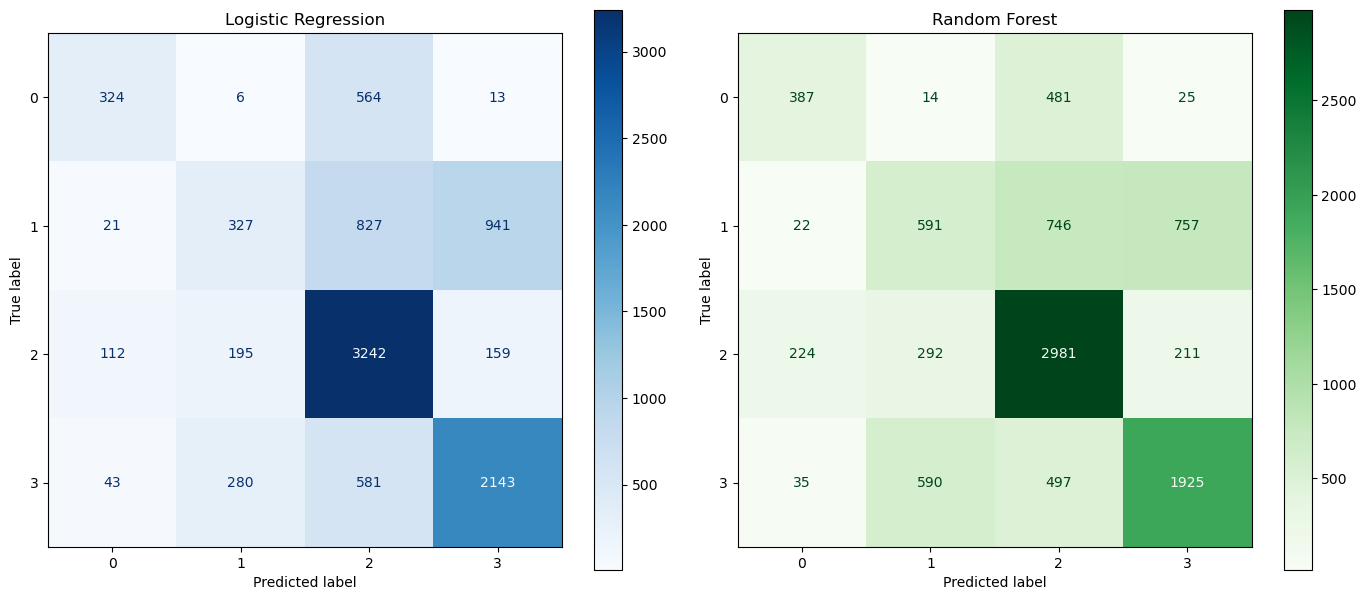

In [12]:
# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, ax=ax[0], cmap='Blues')
ax[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens')
ax[1].set_title("Random Forest")
plt.tight_layout()
plt.show()


### 6.ROC-CURVE

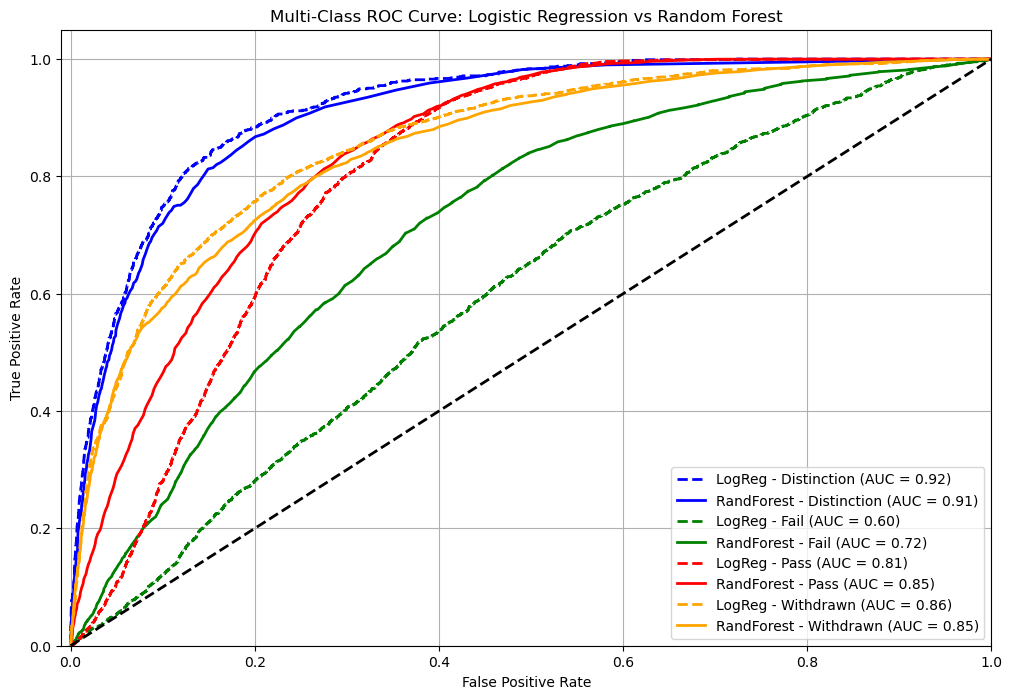

In [30]:
# Encoding categorical and target variables
df_encoded = df.copy()
le_dict = {}
for col in categorical_features + [target]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Scaling numerical features
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])
X = df_encoded[numerical_features + categorical_features]
y = df_encoded[target]
y_bin = label_binarize(y, classes=[0, 1, 2, 3])
class_names = le_dict['final_result'].inverse_transform([0, 1, 2, 3])
n_classes = y_bin.shape[1]
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, stratify=y, test_size=0.3, random_state=42)

# Train Logistic Regression
logreg_model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000))
logreg_model.fit(X_train, y_train_bin)
y_score_logreg = logreg_model.predict_proba(X_test)

# Train Random Forest
rf_model = OneVsRestClassifier(RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42))
rf_model.fit(X_train, y_train_bin)
y_score_rf = rf_model.predict_proba(X_test)

# Calculate ROC and AUC for both algorithms
fpr_logreg, tpr_logreg, roc_auc_logreg = {}, {}, {}
fpr_rf, tpr_rf, roc_auc_rf = {}, {}, {}
for i in range(n_classes):
    fpr_logreg[i], tpr_logreg[i], _ = roc_curve(y_test_bin[:, i], y_score_logreg[:, i])
    roc_auc_logreg[i] = auc(fpr_logreg[i], tpr_logreg[i])

    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Plot both ROC curves
plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'orange']

for i in range(n_classes):
    plt.plot(fpr_logreg[i], tpr_logreg[i], color=colors[i], linestyle='--', lw=2,
             label='LogReg - {0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc_logreg[i]))
    plt.plot(fpr_rf[i], tpr_rf[i], color=colors[i], lw=2,
             label='RandForest - {0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc_rf[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve: Logistic Regression vs Random Forest')
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(r'E:\DM\DM PROJECT\roc_curve_logreg_vs_rf.png')
plt.show()


### 7.MODEL TUNING

In [46]:
# Logistic Regression Tuning
logreg = LogisticRegression(max_iter=1000, multi_class='multinomial')
logreg_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}

logreg_grid = GridSearchCV(logreg, logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_train, y_train)

best_logreg = logreg_grid.best_estimator_
y_pred_logreg = best_logreg.predict(X_test)
logreg_acc = accuracy_score(y_test, y_pred_logreg)

print("Logistic Regression (Tuned)")
print("Best Parameters:", logreg_grid.best_params_)
print("Test Accuracy: {:.2f}%".format(logreg_acc * 100))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


# Random Forest Tuning
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\n Random Forest (Tuned)")
print("Best Parameters:", rf_grid.best_params_)
print("Test Accuracy: {:.2f}%".format(rf_acc * 100))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.

Logistic Regression (Tuned)
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Test Accuracy: 61.74%
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.36      0.47       907
           1       0.40      0.15      0.22      2116
           2       0.62      0.87      0.73      3708
           3       0.66      0.70      0.68      3047

    accuracy                           0.62      9778
   macro avg       0.58      0.52      0.52      9778
weighted avg       0.59      0.62      0.58      9778


 Random Forest (Tuned)
Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Test Accuracy: 60.64%
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.54      0.53       907
           1       0.42      0.36      0.39      2116
           2       0.66      0.75      0.70      3708
           3       0.68      0.62

### 8. FEATURE IMPORTANCE

C:\Users\ACER\AppData\Local\Temp\ipykernel_9424\287177695.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=feat_importance, y=feat_importance.index, palette="viridis")


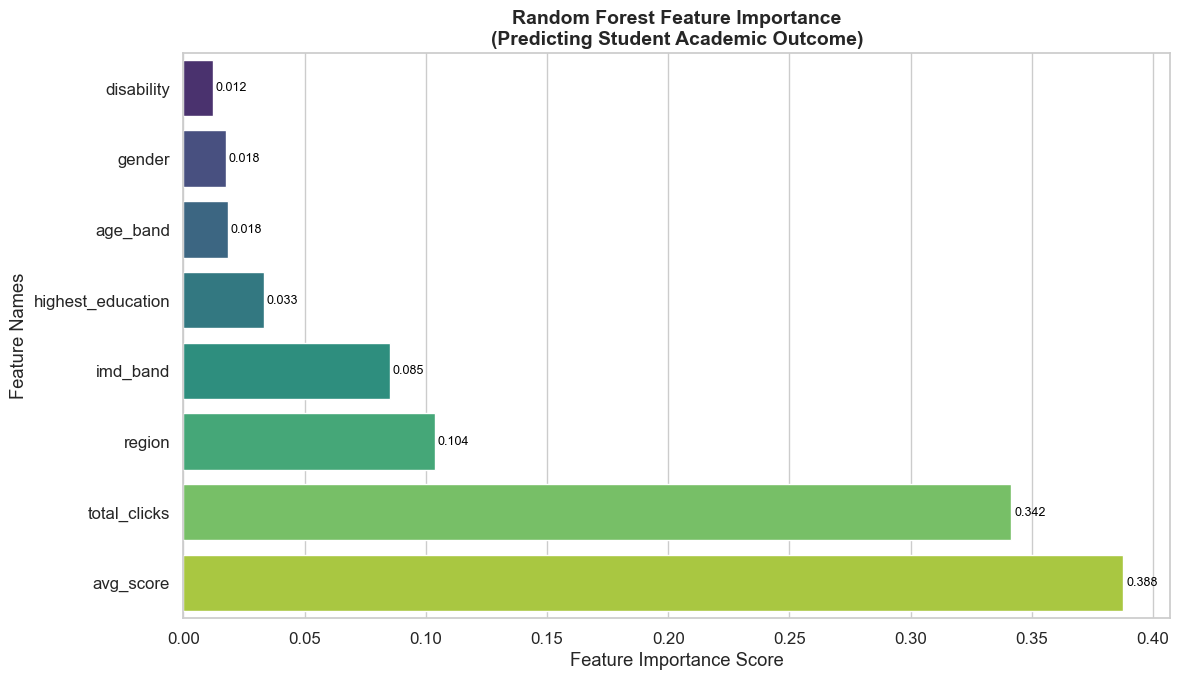

In [44]:
# Calculate feature importances
importances = best_rf.feature_importances_
feature_names = X.columns
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot theme
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=feat_importance, y=feat_importance.index, palette="viridis")
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=2, fontsize=9, color='black')

# Title and axis labels
plt.title("Random Forest Feature Importance\n(Predicting Student Academic Outcome)", fontsize=14, weight='bold')
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Names")
plt.tight_layout()
plt.savefig(r'E:\DM\DM PROJECT\enhanced_feature_importance_rf.png')
plt.show()


### 9. MODEL SUMMARY

In [66]:
comparison_df_classification = pd.DataFrame({
    'Model': [ 
        'Logistic Regression', 
        'Random Forest Classifier'
    ],
    'Accuracy (%)': [61.7, 60.1],
    
})

print("Model Comparison Summary – Dataset 1:\n")
print(comparison_df_classification.to_string(index=False))


Model Comparison Summary – Dataset 1:

                   Model  Accuracy (%)
     Logistic Regression          61.7
Random Forest Classifier          60.1
